In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

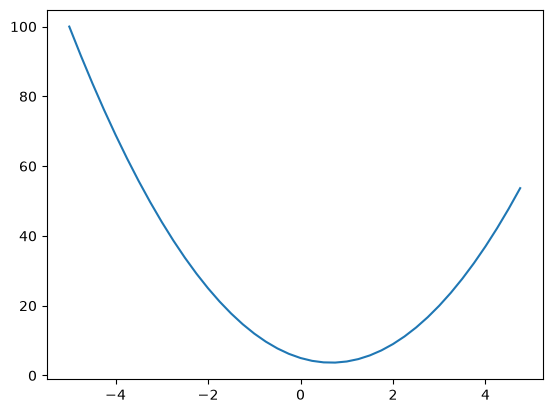

In [4]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [5]:
h = 0.00001
x = 2/3
(f(x + h) - f(x))/h

3.0000002482211127e-05

In [6]:
# lets get more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [7]:
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)


d1 4.0
d2 4.0001
slope 0.9999999999976694


In [ ]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        
        return out

    def __radd__(self, other):
        return self + other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self, ), f'**{other}')

        def _backward():
            # what is the chain rule expression for backpropagating thru the power function?
            # where the power is to the power of some kind of constant
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward

        return out
    
    def __rmul__(self, other): # other * self
        return self * other

    def __truediv__(self, other): # self / other
        return self * other**-1

    def __neg__(self): # -self
        return self * -1

    def __sub__(self, other): # self - other
        return self + (-other)
        
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward

        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [9]:
a = Value(2.0)
b = Value(4.0)
a - b

Value(data=-2.0)

In [10]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the top node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [11]:
def lol():
    h = 0.0001
    
    a = Value(2.0, label='a')
    b = Value(-3.0, label = 'b')
    c = Value(10.0, label = 'c')
    e= a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label = 'f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label = 'b')
    b.data += h
    c = Value(10.0, label = 'c')
    e= a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label = 'f')
    L = d * f; L.label = 'L'
    L2 = L.data

    print((L2 - L1)/h)

lol()

-4.000000000008441


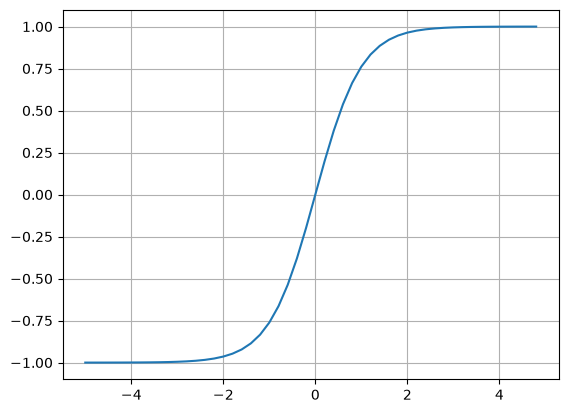

In [12]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();

In [13]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# (x1 * w1) + (x2 * w2)+ b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.label = 'o'

o.backward()

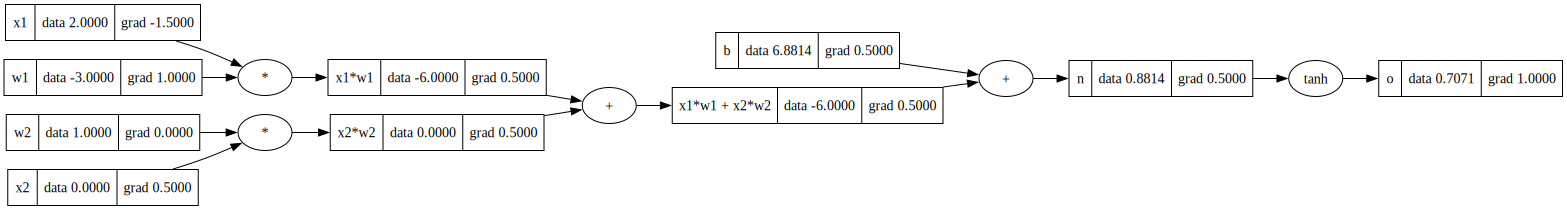

In [14]:
draw_dot(o)

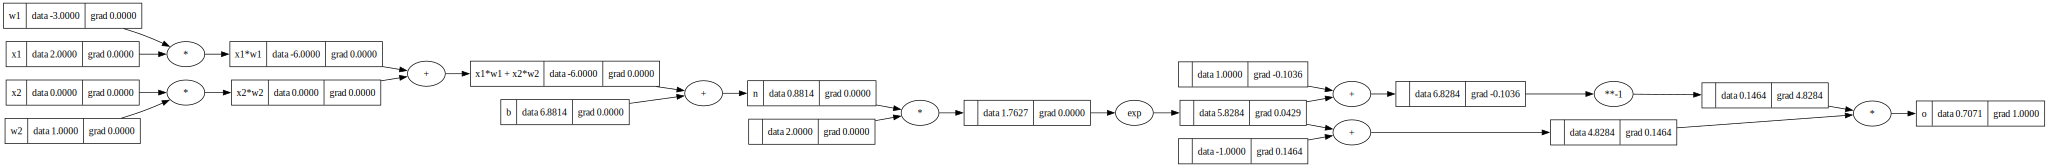

In [15]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# (x1 * w1) + (x2 * w2)+ b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

# o = n.tanh(); o.label = 'o'
# ---- change how we define o
e = (2*n).exp()
o = (e - 1)/(e + 1)
# ----
o.label='o'
o.backward()
draw_dot(o)

In [16]:
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
topo

[Value(data=1),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=0.0),
 Value(data=-3.0),
 Value(data=2.0),
 Value(data=-6.0),
 Value(data=-6.0),
 Value(data=6.881373587019543),
 Value(data=0.8813735870195432),
 Value(data=2),
 Value(data=1.7627471740390863),
 Value(data=5.828427124746192),
 Value(data=6.828427124746192),
 Value(data=0.1464466094067262),
 Value(data=-1),
 Value(data=4.828427124746192),
 Value(data=0.7071067811865477)]

In [17]:
o.grad = 1.0

In [18]:
o._backward()

In [19]:
n._backward()

In [20]:
b._backward()

In [21]:
x1w1x2w2._backward()

In [22]:
x2w2._backward()
x1w1._backward()

In [23]:
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

In [24]:
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad


In [25]:
x1w1.grad = 0.5
x2w2.grad = 0.5

In [26]:
x1w1x2w2.grad = 0.5
b.grad = 0.5

In [27]:
n.grad = 0.5

In [28]:
o.grad = 1.0

In [29]:
1 - o.data**2

0.4999999999999998

In [30]:
# o = tanh(n)
#w what is do/dn?
# do/dn = 1 - tanh(n)**2
# which is 1 - o**2

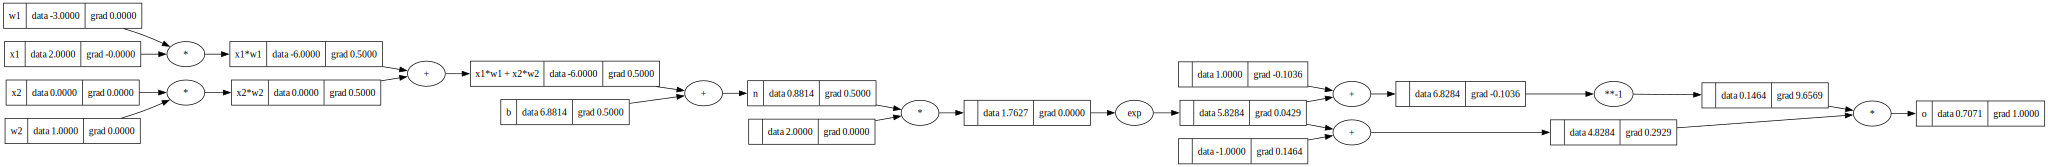

In [31]:
draw_dot(o)

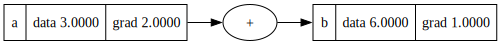

In [32]:
# a bug,incorrect
a = Value(3.0, label='a')
b = a + a; b.label='b'
b.backward()
draw_dot(b)

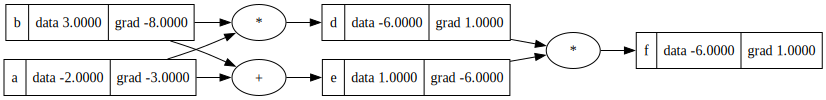

In [33]:
# another example of the bug
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b; d.label='d'
e = a + b; e.label='e'
f = d * e; f.label='f'

f.backward()

draw_dot(f)

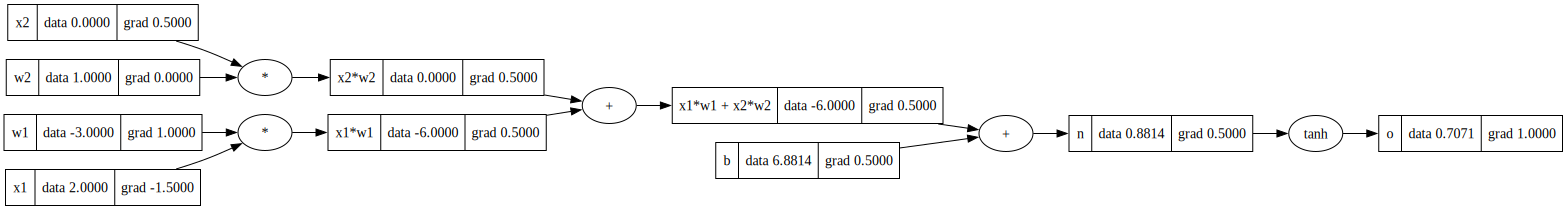

In [46]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# (x1 * w1) + (x2 * w2)+ b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.label = 'o'

o.backward()
draw_dot(o)

In [57]:
import torch
import random

x1 = torch.Tensor([2.0]).double()    ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()    ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()   ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()   ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()   ; b.requires_grad = True

n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [89]:
# building a neural net

class Neuron:
    # the constructor will take number of inputs to the neuron
    # and create a weight that is rand n between -1 and 1 for every input
    # and a bias that controls that controls the overall trigger happiness of the neuron
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        # w * x + b
        # we need to multiply all the elements of w with all elements of x pairwise

        # zip takes two iterators and creates a new iterator that iterates over the
        # tuples of their corresponding entries
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b) # activation
        out = act.tanh()
        return out

    # collects paramaters of the neural net all in one array
    def parameters(self):
        return self.w + [self.b]

# what is a layer of neurons?
# its just a set of neurons evaluated independently
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
        # identical to above
        # params = []
        # for neuron in self.neurons:
        #     ps neuron.parameters()
        #     params.extend(ps)
        # return params

# in an MLP, layers just feed into each other sequentially (see visualizations online)
class MLP:
    # we take the number of inputs
    # but instead of taking a single nout (number of neurons in a single layer)
    # we take a list of nouts and this listifies the sizes of all the layers that we want in our MLP
    def __init__(self, nin, nouts):
        # we put them all together
        sz = [nin] + nouts
        # iterate over consecutive pairs of these sizes and create layer objects for them
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    # then we call them sequentially
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [91]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=-0.17946406866974565)

In [93]:
n.parameters()

[Value(data=0.9530368599114778),
 Value(data=-0.09869680258415348),
 Value(data=0.5317869344433199),
 Value(data=-0.27396182402096647),
 Value(data=0.5963381092838096),
 Value(data=0.8213145846787433),
 Value(data=-0.8521695214895695),
 Value(data=-0.8651960390065689),
 Value(data=0.8701695308707678),
 Value(data=0.3816616016005556),
 Value(data=0.965556034117732),
 Value(data=0.7353328903332068),
 Value(data=0.8772579520890909),
 Value(data=0.994535827326964),
 Value(data=-0.09544553451316085),
 Value(data=-0.5535627314145488),
 Value(data=0.6038356659059545),
 Value(data=-0.7726734737786511),
 Value(data=0.9155936075563493),
 Value(data=-0.6711720935019743),
 Value(data=-0.1204664185621882),
 Value(data=-0.21927878601198358),
 Value(data=-0.9561912591506976),
 Value(data=-0.866567030779277),
 Value(data=-0.41651600985647064),
 Value(data=0.7220254105800854),
 Value(data=0.7442865255280466),
 Value(data=-0.6201631419706921),
 Value(data=-0.6529245709317204),
 Value(data=0.357029988493

In [132]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=-0.7359788862154791)

In [133]:
# data set sample
# with 4 examples (4 possible inputs)
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]

ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [150]:
# gradient descent loop
for k in range(20):
    # forward pass
        # the loss
        # the trick used in deep learning is to calculate a single number that somehow measures the
        # total performance of a neural net
        
        # the mean squared error loss
        # for each one of the 4 desired targets, we are taking the prediction and the ground truth
        # then subtracting them and squaring them
    ypred = [n(x) for x in xs]
    # evaluate the loss
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    # backward pass
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    # update
        # we want to iterate for every p in n.parameters
        # a tiny update in this gradient descent scheme
        # in gradient descent, we think of the gradient as a vector pointing in the direction of increased loss
        # we modify p.data by a small step size in the direction of the gradient
    for p in n.parameters():
        p.data += -0.05 * p.grad

    print(k, loss.data)

# Most Common Neural Net Mistakes (according to Andrej Karpathy)
# - you didnt try to overfit a single batch first
# - you forgot to toggle train/eval mode for the net
# - you forgot .zero_grad() (in pytorch) before .backward()
# - you passed softmaxed outputs to a loss that expects raw logits

0 0.0031034768473764585
1 0.0030799230356575013
2 0.0030567022944857063
3 0.0030338078132328217
4 0.0030112329625399054
5 0.0029889712883941506
6 0.0029670165064341197
7 0.002945362496474286
8 0.0029240032972381253
9 0.002902933101291345
10 0.0028821462501662453
11 0.0028616372296686177
12 0.002841400665359846
13 0.0028214313182062575
14 0.0028017240803887076
15 0.0027822739712656083
16 0.002763076133483008
17 0.0027441258292253135
18 0.0027254184366011197
19 0.0027069494461581215


In [151]:
ypred

[Value(data=0.9666694705366068),
 Value(data=-0.9959925961185986),
 Value(data=-0.9644212227407123),
 Value(data=0.9822766658127394)]

In [157]:
n(x)

Value(data=0.9667769297905762)

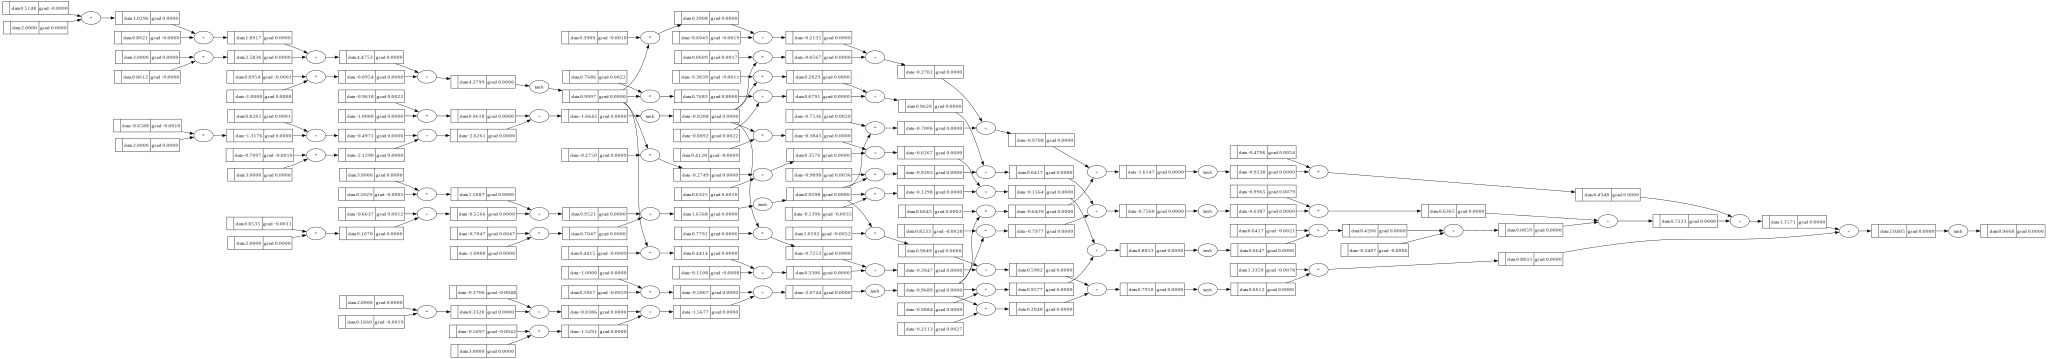

In [156]:
draw_dot(n(x))

In [73]:
# dot = draw_dot(n(x))
# dot.render('computational_graph', format='png', cleanup=True)

'computational_graph.png'